In [ ]:
#LDA PROJECT - LINEAR DISCRIMINANT ANALYSIS

In [3]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [10]:
df=pd.read_csv("/content/sephora_website_dataset.csv")
df.head(4)

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,limited_edition,limited_time_offer
0,2218774,Acqua Di Parma,Fragrance,Blu Mediterraneo MINIATURE Set,4,4,3002,66.0,75.0,0,0
1,2044816,Acqua Di Parma,Cologne,Colonia,5,76,2700,66.0,66.0,0,0
2,1417567,Acqua Di Parma,Perfume,Arancia di Capri,5,26,2600,180.0,180.0,0,0
3,1417617,Acqua Di Parma,Perfume,Mirto di Panarea,5,23,2900,120.0,120.0,0,0


In [11]:
df.shape

(9168, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9168 non-null   int64  
 1   brand               9168 non-null   object 
 2   category            9168 non-null   object 
 3   name                9168 non-null   object 
 4   rating              9168 non-null   int64  
 5   number_of_reviews   9168 non-null   int64  
 6   love                9168 non-null   int64  
 7   price               9168 non-null   float64
 8   value_price         9168 non-null   float64
 9   limited_edition     9168 non-null   int64  
 10  limited_time_offer  9168 non-null   int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 788.0+ KB


In [13]:
df.columns

Index(['id', 'brand', 'category', 'name', 'rating', 'number_of_reviews',
       'love', 'price', 'value_price', 'limited_edition',
       'limited_time_offer'],
      dtype='object')

In [14]:
df.describe()

,id,rating,number_of_reviews,love,price,value_price,limited_edition,limited_time_offer
count,9.168000e+03,9168.000000,9168.000000,9.168000e+03,9168.000000,9168.00000,9168.000000,9168.000000
mean,1.962952e+06,4.244983,282.139180,1.627859e+04,50.063237,51.82359,0.091841,0.000327
std,3.859714e+05,1.096011,890.642028,4.260651e+04,47.164989,49.45902,0.288817,0.018087
min,5.000000e+01,0.000000,0.000000,0.000000e+00,2.000000,2.00000,0.000000,0.000000
25%,1.819453e+06,4.000000,10.000000,1.600000e+03,24.000000,25.00000,0.000000,0.000000
50%,2.072354e+06,4.000000,46.000000,4.800000e+03,35.000000,35.00000,0.000000,0.000000
75%,2.230591e+06,5.000000,210.000000,1.380000e+04,59.000000,60.00000,0.000000,0.000000
max,2.359685e+06,5.000000,19000.000000,1.300000e+06,549.000000,549.00000,1.000000,1.000000


In [15]:
df.isna().sum()

,0
id,0
brand,0
category,0
name,0
rating,0
number_of_reviews,0
love,0
price,0
value_price,0
limited_edition,0


In [16]:
#how to convert string to values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [19]:
df["brand"]=le.fit_transform(df.brand)
df["category"]=le.fit_transform(df.category)
df["name"]=le.fit_transform(df.name)

In [ ]:
df.rating.fillna(df.rating.mean(),inplace=True)
df.reviews.fillna(df.reviews.mean(),inplace=True)

/tmp/ipykernel_2265/3686014126.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.rating.fillna(df.rating.mean(),inplace=True)
/tmp/ipykernel_2265/3686014126.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [20]:
df.rating.value_counts()

,count
rating,
5,4399
4,3904
0,398
3,396
2,48
1,23


<Axes: xlabel='rating', ylabel='count'>

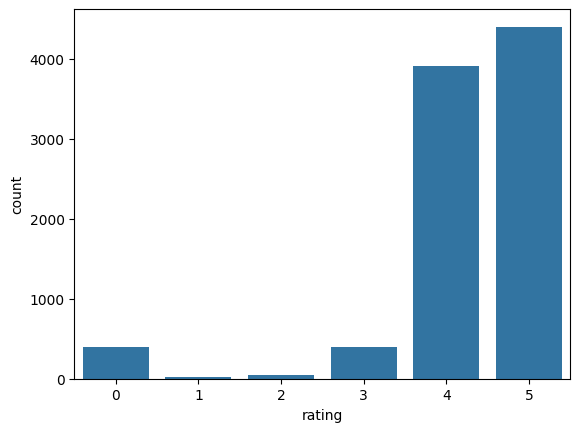

In [21]:
sn.countplot(x='rating', data=df)

In [24]:
df.limited_edition.value_counts()

,count
limited_edition,
0,8326
1,842


<Axes: xlabel='limited_edition', ylabel='count'>

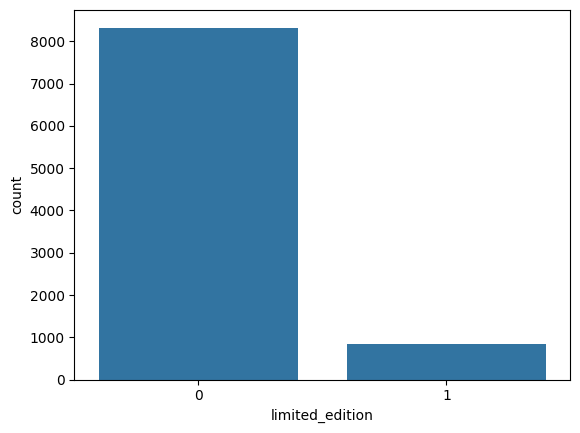

In [25]:
sn.countplot(x='limited_edition', data=df)

<Axes: xlabel='rating'>

<Figure size 7000x4000 with 0 Axes>

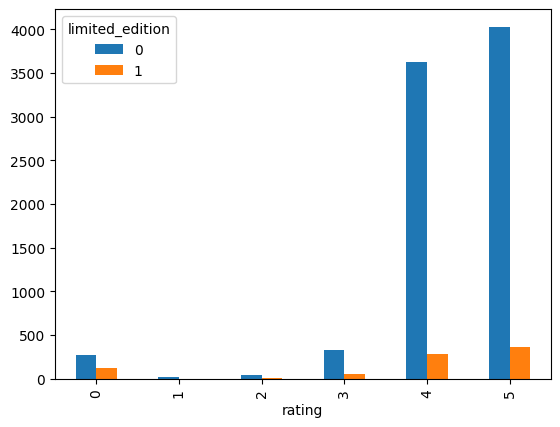

In [37]:
plt.figure(figsize=(70,40))
pd.crosstab(df.rating,df.limited_edition).plot(kind="bar")

<Axes: xlabel='rating'>

<Figure size 7000x4000 with 0 Axes>

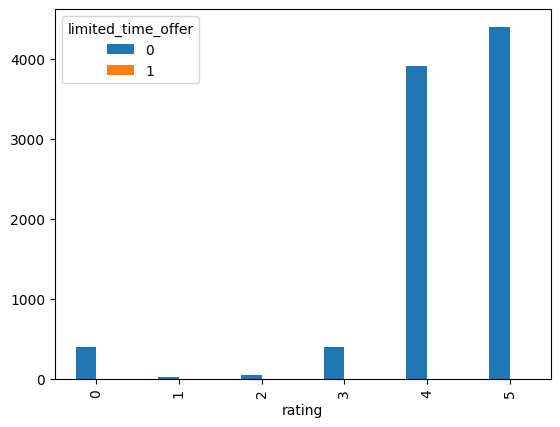

In [40]:
plt.figure(figsize=(70,40))
pd.crosstab(df.rating,df.limited_time_offer).plot(kind="bar")

<Axes: >

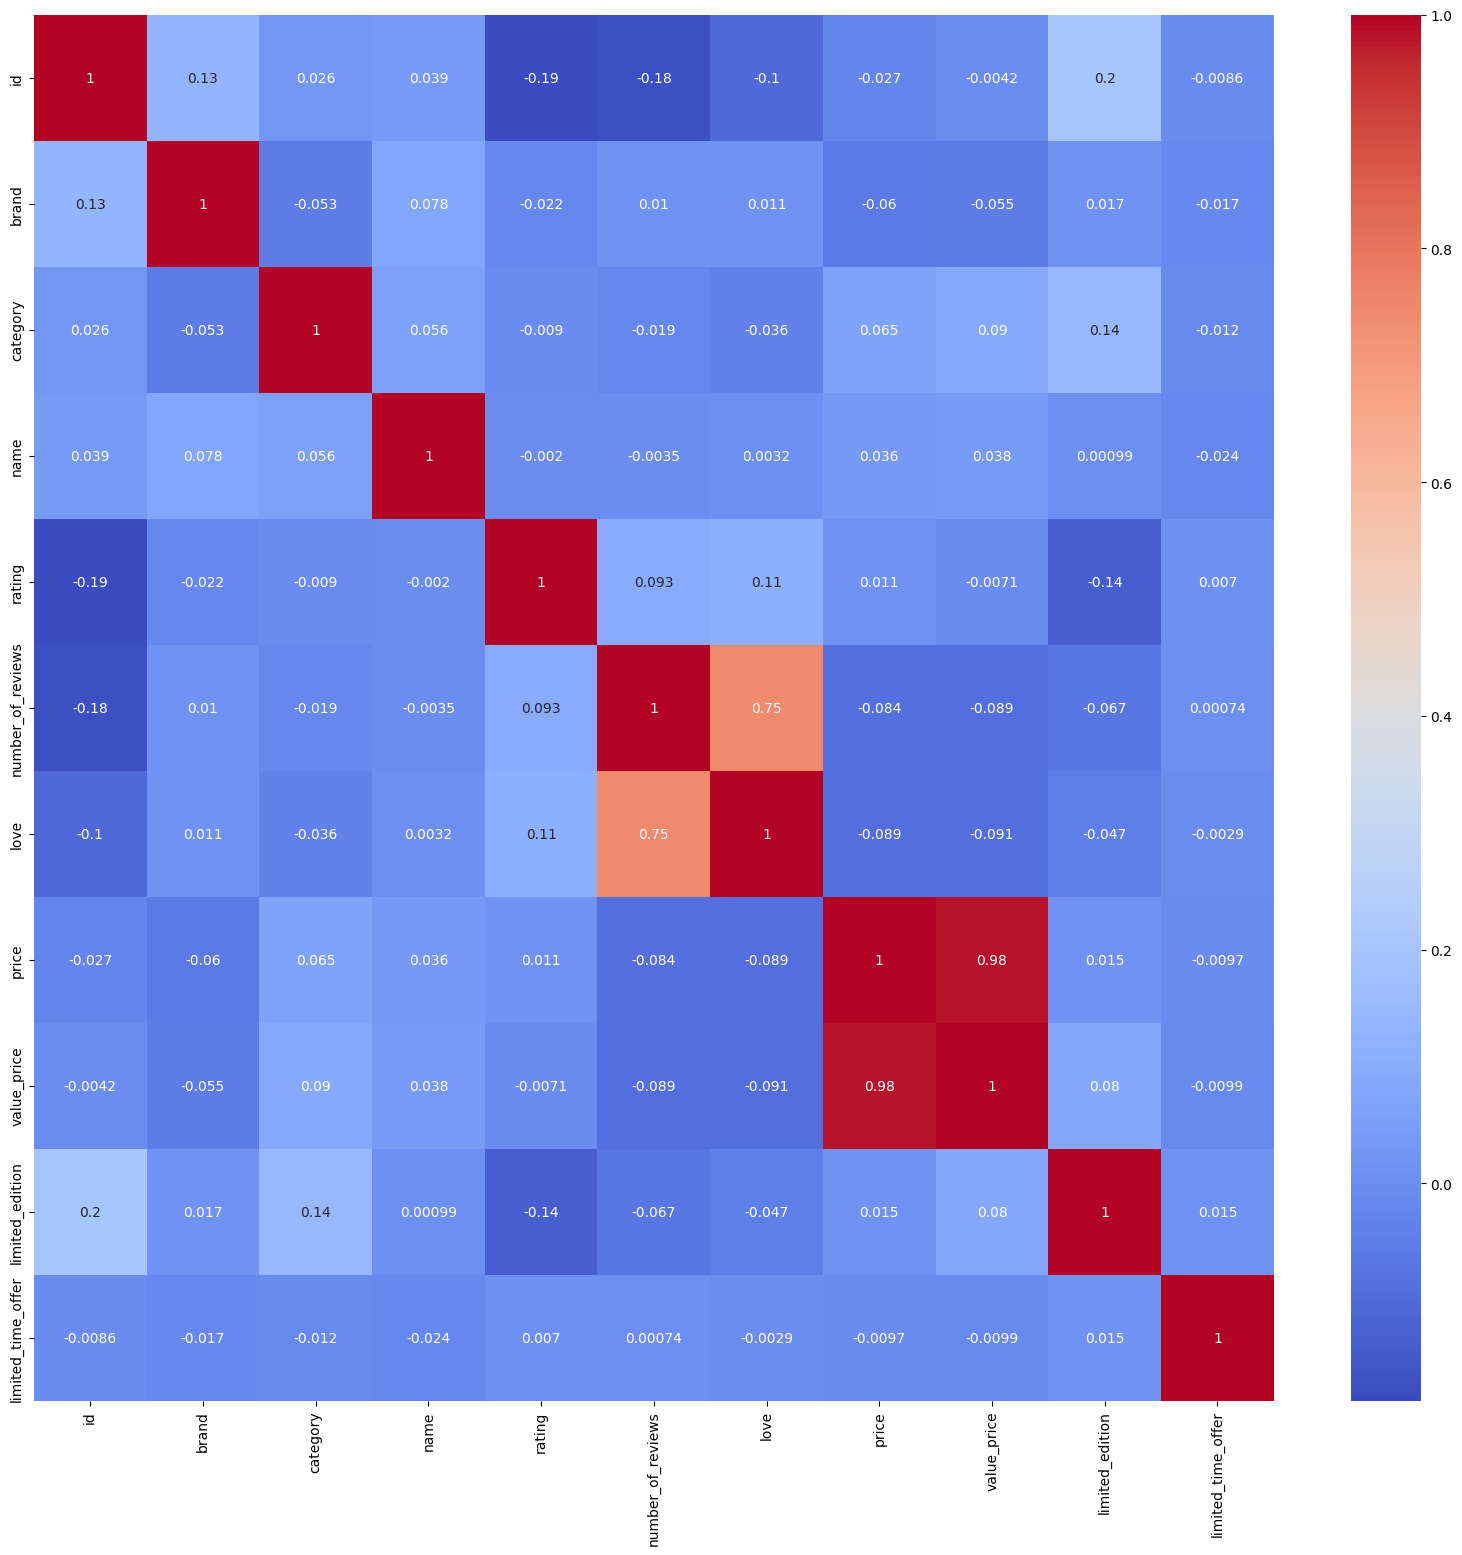

In [41]:
plt.figure(figsize=(20,18))
sn.heatmap(df.corr(),annot=True,cmap="coolwarm")

In [42]:
#removing the outlier
q1=df.quantile(0.0)   ## 25 %
q3=df.quantile(0.92)  ## 75 %
iqr=q3-q1

In [43]:
## to save in new dtaframe
df2=df[~((df<(q1-1.5*iqr))| (df>(q3+1.5*iqr)))]

In [44]:
df2.head(2)

,id,brand,category,name,rating,number_of_reviews,love,price,value_price,limited_edition,limited_time_offer
0,2218774,4,71,1079,4,4.0,3002.0,66.0,75.0,0,0.0
1,2044816,4,28,1920,5,76.0,2700.0,66.0,66.0,0,0.0


In [45]:
df3=df2.dropna()

In [46]:
df3.shape

(8814, 11)

<Axes: >

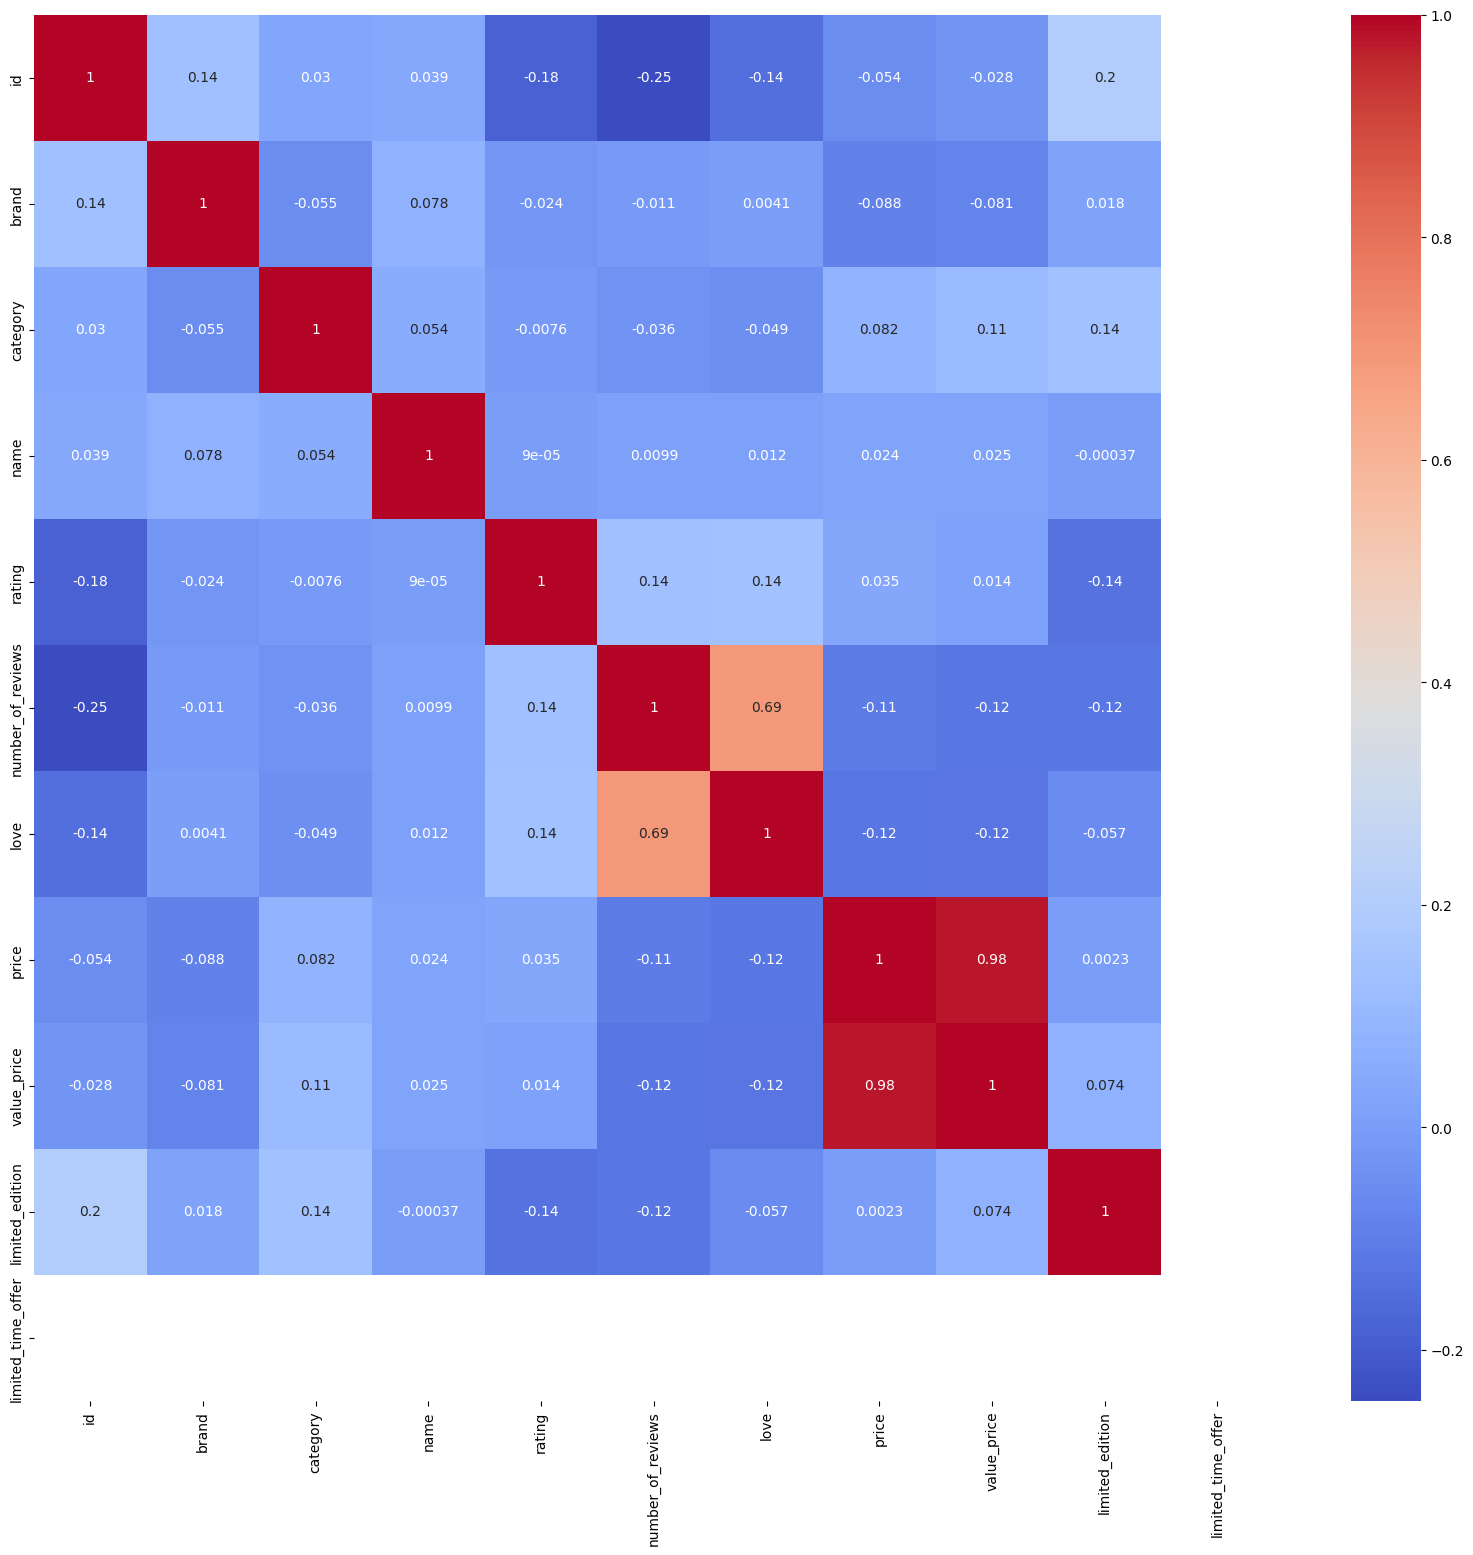

In [47]:
plt.figure(figsize=(20,18))
sn.heatmap(df3.corr(),annot=True,cmap="coolwarm")

removing the outlier

In [48]:
corr_matrix=df3.corr()

In [49]:
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)

#For loop to filter columns
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if corr_matrix.iloc[i,j] >= 0.9:
            if columns[j]:
                columns[j] = False

# Selected column store into a variable
selected_columns = df3.columns[columns]
df_with_filtered_columns = df3[selected_columns]

In [50]:
df_with_filtered_columns.columns

Index(['id', 'brand', 'category', 'name', 'rating', 'number_of_reviews',
       'love', 'price', 'limited_edition', 'limited_time_offer'],
      dtype='object')

In [51]:
x=df_with_filtered_columns[['id', 'brand', 'category', 'name', 'rating', 'number_of_reviews',
       'love', 'price', 'limited_time_offer']]
y=df_with_filtered_columns['limited_edition']

In [52]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

FEATURE SCALING

In [54]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [55]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
x_train = lda.fit_transform(x_train, y_train)
x_test = lda.fit_transform(x_test,y_test)

In [56]:
lda.fit(x_train,y_train)

LinearDiscriminantAnalysis()

In [57]:
lda.score(x_test,y_test)

0.9245604083947816

In [58]:
lda.predict(x_test)

array([0, 0, 0, ..., 0, 0, 0])

In [59]:
y_predict=lda.predict(x_test)

In [60]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1621
           1       0.63      0.15      0.25       142

    accuracy                           0.92      1763
   macro avg       0.78      0.57      0.60      1763
weighted avg       0.91      0.92      0.90      1763



In [62]:
from sklearn.metrics import confusion_matrix
y_predict=lda.predict(x_test)
cm=confusion_matrix(y_test,y_predict)
print(cm)

[[1608   13]
 [ 120   22]]


<Axes: >

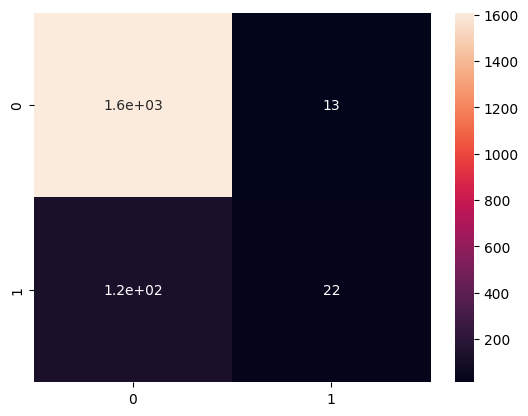

In [63]:
sn.heatmap(cm,annot=True)

In [ ]:
## roc curve is alos know as auc (tp vs fp) / precison recall cure (tp vs predicted positive)

In [64]:
y_predict=lda.predict_proba(x_test)

In [65]:
proba= y_predict[:,1]

In [66]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_test,proba)

Text(0.5, 1.0, 'ROC_CURVE')

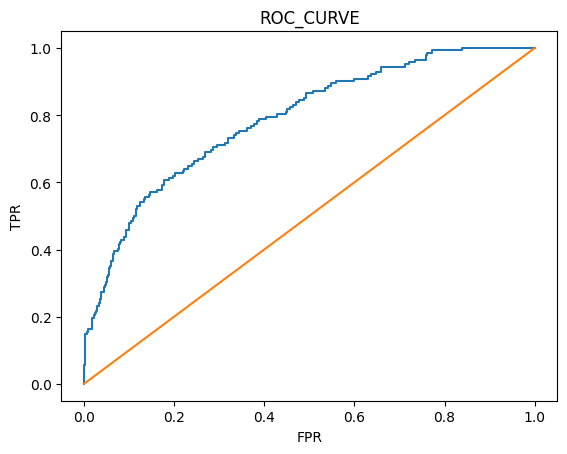

In [67]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC_CURVE")

In [68]:
from sklearn.metrics import roc_auc_score
score=roc_auc_score(y_test,proba)
score

np.float64(0.7876158865593315)

MODEL BUILDING WITH HYPER-PARAMETER


In [81]:
param_grid = {
    "solver":['svd',"lsqr", "eigen"],
    "shrinkage":[0,0.5,1],
    "priors":[None],
    "n_components":[1,2,],
    "store_covariance":[False],
    "tol":[0.0001],
    "covariance_estimator":[None]}

GRID SEARCH CV

In [82]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(LinearDiscriminantAnalysis(),param_grid,cv=5) ## cv=5

In [83]:
grid.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py", line 700, in fit
    raise NotImplementedErro

GridSearchCV(cv=5, estimator=LinearDiscriminantAnalysis(),
             param_grid={'covariance_estimator': [None], 'n_components': [1, 2],
                         'priors': [None], 'shrinkage': [0, 0.5, 1],
                         'solver': ['svd', 'lsqr', 'eigen'],
                         'store_covariance': [False], 'tol': [0.0001]})

In [84]:
grid.score(x_test,y_test)

0.9245604083947816

In [85]:
grid.best_estimator_

LinearDiscriminantAnalysis(n_components=1, shrinkage=0, solver='lsqr')

In [86]:
grid.best_params_

{'covariance_estimator': None,
 'n_components': 1,
 'priors': None,
 'shrinkage': 0,
 'solver': 'lsqr',
 'store_covariance': False,
 'tol': 0.0001}

In [87]:
grid.best_score_

np.float64(0.9051199541595668)

RANDOMIZED SEARCH CV

In [90]:
from sklearn.model_selection import RandomizedSearchCV

In [92]:
random = RandomizedSearchCV(LinearDiscriminantAnalysis(),param_grid,cv=5)

In [94]:
random.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py", line 700, in fit
    raise NotImplementedError

RandomizedSearchCV(cv=5, estimator=LinearDiscriminantAnalysis(),
                   param_distributions={'covariance_estimator': [None],
                                        'n_components': [1, 2],
                                        'priors': [None],
                                        'shrinkage': [0, 0.5, 1],
                                        'solver': ['svd', 'lsqr', 'eigen'],
                                        'store_covariance': [False],
                                        'tol': [0.0001]})

In [95]:
random.score(x_test,y_test)

0.9245604083947816

In [96]:
random.best_estimator_

LinearDiscriminantAnalysis(n_components=1, shrinkage=0, solver='eigen')

In [97]:
random.best_params_

{'tol': 0.0001,
 'store_covariance': False,
 'solver': 'eigen',
 'shrinkage': 0,
 'priors': None,
 'n_components': 1,
 'covariance_estimator': None}

In [99]:
random.best_score_

np.float64(0.9051199541595668)